In [57]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import tensorflow
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import kerasAC 
from kerasAC.generators.tiledb_predict_generator import *
from kerasAC.tiledb_config import *
import tiledb 
from scipy.special import softmax
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

In [3]:
import pickle 
baseline=pickle.load(open("HEPG2.DNASE.baseline.fold0.deepSHAP",'rb'))

In [4]:
corrected=pickle.load(open("HEPG2.DNASE.bias_corrected_bpnet_tobias.fold0.deepSHAP",'rb'))

In [5]:
unplugged=pickle.load(open("HEPG2.DNASE.bias_corrected_bpnet_tobias.unplugged.fold0.deepSHAP",'rb'))

In [6]:
## get distribution of JSD & MNNLL
dist=pd.read_csv("/srv/scratch/annashch/deeplearning/profile/vis_bias_cor/jsd_mnll/hepg2.dnase.mnnll.txt",header=0,sep='\t')

In [11]:
dist["correct_minus_baseline"]=dist['bpnet.tobias']-dist['bpnet']

In [12]:
dist.head()

,chrom,summit,bpnet.tobias,tobias,baseline,bpnet,correct_minus_baseline
0,chr1,100036951,1053.571173,992.065866,892.044682,935.572497,117.998676
1,chr1,100038093,3226.922190,4391.851622,1108.806237,4754.806232,-1527.884042
2,chr1,100038860,2595.530148,4377.461010,942.491890,4622.463515,-2026.933367
3,chr1,1000442,2797.079998,2130.606694,3437.661857,2179.118037,617.961961
4,chr1,1000707,2927.789317,2148.404504,3356.928999,2132.116886,795.672431


In [33]:
#remove mnnll scores in top quantile 
thresh=dist.quantile(0.8)


In [36]:
good_scores=dist[dist['bpnet.tobias']<thresh['bpnet.tobias']]
good_scores=good_scores[good_scores['baseline']<thresh['baseline']]


In [37]:
good_scores

,chrom,summit,bpnet.tobias,tobias,baseline,bpnet,correct_minus_baseline
0,chr1,100036951,1053.571173,992.065866,892.044682,935.572497,117.998676
10,chr1,100188136,1357.855101,1254.327648,497.454082,1318.629893,39.225208
11,chr1,1001948,1053.986166,1077.069916,1363.333626,1063.566660,-9.580494
12,chr1,100249586,1331.409958,1228.389337,1348.604794,1286.382409,45.027549
13,chr1,100249896,1288.389724,1208.287537,1250.685932,1225.801033,62.588692
...,...,...,...,...,...,...,...
69431,chrY,7310709,1547.515195,1502.392136,1403.636539,1265.000992,282.514202
69432,chrY,7310893,1650.911212,1623.989525,1394.091332,1422.552657,228.358555
69434,chrY,7415512,1748.484929,1560.691514,1646.125956,1718.125895,30.359034
69435,chrY,8370845,827.920795,880.810465,1746.506362,798.883664,29.037130


In [38]:
max(good_scores['baseline'])

2134.32950057

In [39]:
max(dist['baseline'])

28611.69868903

In [42]:
good_scores.sort_values(by='correct_minus_baseline',inplace=True)

In [77]:
good_scores.head()

,chrom,summit,bpnet.tobias,tobias,baseline,bpnet,correct_minus_baseline
37110,chr2,208025985,1928.773868,3069.500339,1538.625068,4364.737090,-2435.963222
251,chr1,108033666,1670.896983,2942.744827,773.416668,3952.092263,-2281.195280
11836,chr13,98143039,1965.722768,2026.663120,1571.090334,4073.545114,-2107.822346
38293,chr2,222837886,2003.200857,2783.563752,1140.140967,4060.317839,-2057.116982
32655,chr2,111051058,1314.415504,2609.374888,810.465595,3256.420988,-1942.005484


In [78]:
region=tuple(['chr1',108033666])

In [63]:
def extract_region(region,interp_dict):
    label_prof=interp_dict['label_prof'][region]
    label_sum=interp_dict['label_sum'][region]
    pred_prof=interp_dict['pred_prof'][region]
    pred_sum=interp_dict['pred_sum'][region]
    profile_shap=interp_dict['profile_shap'][region]
    count_shap=interp_dict['count_shap'][region]
    seq=interp_dict['seq'][region]
    #get the min & max values, to use in ylims for plotting 
    minval_perf=min([label_prof.min(),pred_prof.min()])
    maxval_perf=max([label_prof.max(),pred_prof.max()])
    minval_shap=min([profile_shap.min(), count_shap.min()])
    maxval_shap=max([profile_shap.max(), count_shap.max()])
    return label_prof, label_sum, pred_prof, pred_sum, profile_shap, count_shap, seq, minval_perf, maxval_perf, minval_shap, maxval_shap

In [79]:
baseline_region_vals=extract_region(region,baseline)
corrected_region_vals=extract_region(region,corrected)
unplugged_region_vals=extract_region(region,unplugged)
minval_perf=min([baseline_region_vals[7],corrected_region_vals[7], unplugged_region_vals[7]])
maxval_perf=min([baseline_region_vals[8],corrected_region_vals[8], unplugged_region_vals[8]])
minval_shap=min([baseline_region_vals[9],corrected_region_vals[9], unplugged_region_vals[9]])
maxval_shap=min([baseline_region_vals[10],corrected_region_vals[10], unplugged_region_vals[10]])


In [74]:
def make_plot(toplot_b,toplot_c,toplot_u,region,ymin_perf,ymax_perf,ymin_shap,ymax_shap,xmin=0,xmax=1000,offset=173):
    plt.rcParams["figure.figsize"]=15,20
    fig, axes = plt.subplots(9, 1)
    axes[0].plot(toplot_b[0][xmin+offset:xmax+offset],label='Label Prob',color='b')
    axes[0].plot(toplot_b[2][xmin+offset:xmax+offset],label='Pred Prob',color='r')
    axes[0].set_title("Baseline HEPG2 DNASE:"+str(region)+"Counts Label:"+str(toplot_b[1])+":"+"Counts Pred:"+str(toplot_b[3]))
    axes[0].legend() 
    axes[0].set_ylim(ymin_perf,ymax_perf)
    
    axes[1]=plot_seq_importance(toplot_b[4],toplot_b[6],xlim=(offset+xmin,offset+xmax),axes=axes[1])
    axes[1].set_title("Profile Loss SHAP")        
    axes[1].set_ylim(ymin_shap,ymax_shap)
    
    axes[2]=plot_seq_importance(toplot_b[5],toplot_b[6],xlim=(offset+xmin,offset+xmax),axes=axes[2])
    axes[2].set_title("Count Loss SHAP")
    axes[2].set_ylim(ymin_shap,ymax_shap)
    
    axes[3].plot(toplot_c[0][xmin+offset:xmax+offset],label='Label Prob',color='b')
    axes[3].plot(toplot_c[2][xmin+offset:xmax+offset],label='Pred Prob',color='r')    
    axes[3].set_title("Corrected HEPG2 DNASE:"+str(region)+"Counts Label:"+str(toplot_c[1])+":"+"Counts Pred:"+str(toplot_c[3]))
    axes[3].legend()
    axes[3].set_ylim(ymin_perf,ymax_perf)

    axes[4]=plot_seq_importance(toplot_c[4],toplot_c[6],xlim=(xmin+offset,xmax+offset),axes=axes[4])
    axes[4].set_title("Profile Loss SHAP")
    axes[4].set_ylim(ymin_shap,ymax_shap)
  
    axes[5]=plot_seq_importance(toplot_c[5],toplot_c[6],xlim=(xmin+offset,xmax+offset),axes=axes[5])
    axes[5].set_title("Count Loss SHAP")
    axes[5].set_ylim(ymin_shap,ymax_shap)

    axes[6].plot(toplot_u[0][xmin+offset:xmax+offset],label='Label Prob',color='b')
    axes[6].plot(toplot_u[2][xmin+offset:xmax+offset],label='Pred Prob',color='r')
    axes[6].set_title("Unplugged HEPG2 DNASE:"+str(region)+"Counts Label:"+str(toplot_u[1])+":"+"Counts Pred:"+str(toplot_u[3]))
    axes[6].legend()
    axes[6].set_ylim(ymin_perf,ymax_perf)
        
    axes[7]=plot_seq_importance(toplot_u[4],toplot_u[6],xlim=(xmin+offset,xmax+offset),axes=axes[7])
    axes[7].set_title("Profile Loss SHAP")
    axes[7].set_ylim(ymin_shap,ymax_shap)
    
    axes[8]=plot_seq_importance(toplot_u[5],toplot_u[6],xlim=(xmin+offset,xmax+offset),axes=axes[8])
    axes[8].set_title("Count Loss SHAP")
    axes[8].set_ylim(ymin_shap,ymax_shap)
    plt.xticks(list(range(xmin, xmax, 50,)))
    plt.subplots_adjust(hspace=0.6)
    plt.show()

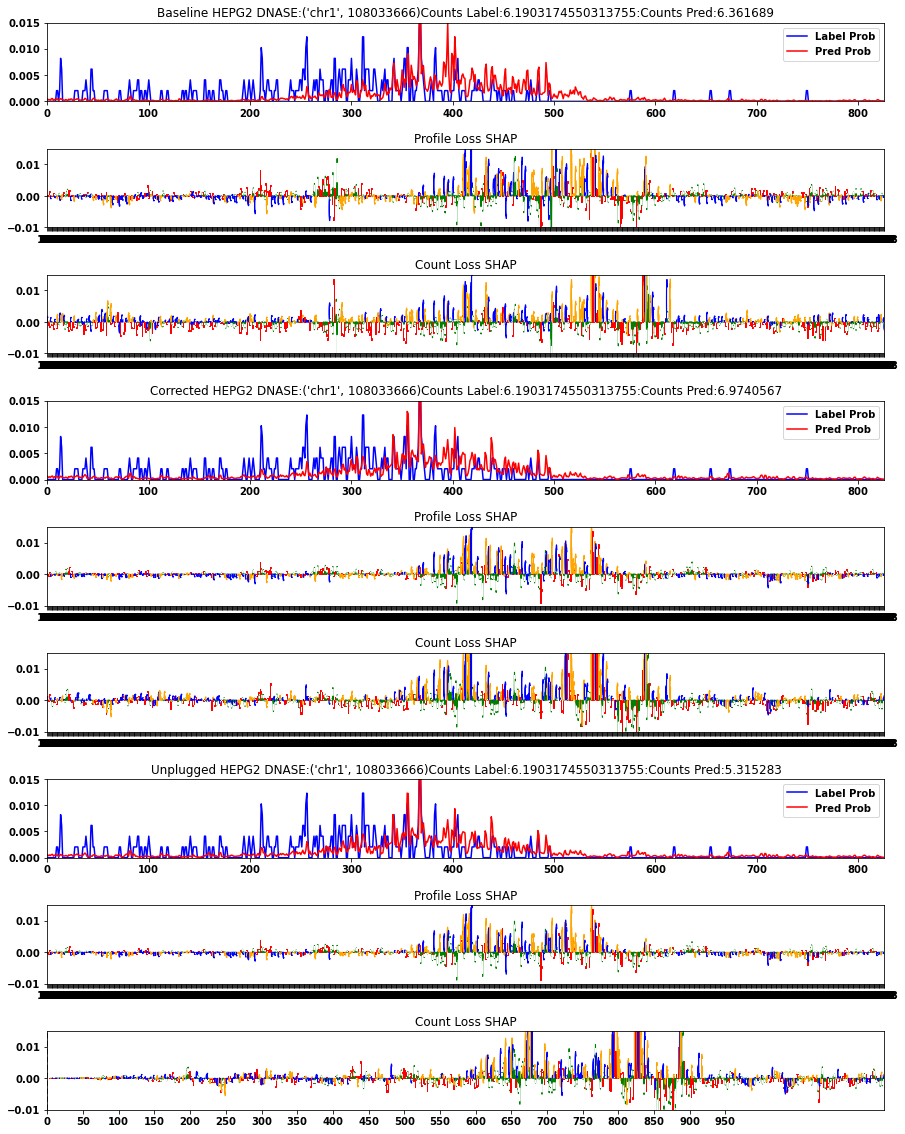

In [80]:
make_plot(baseline_region_vals,
        corrected_region_vals, 
        unplugged_region_vals,
        region,
        ymin_perf=minval_perf,
        ymax_perf=0.015,
        ymin_shap=-0.01,
        ymax_shap=0.015)

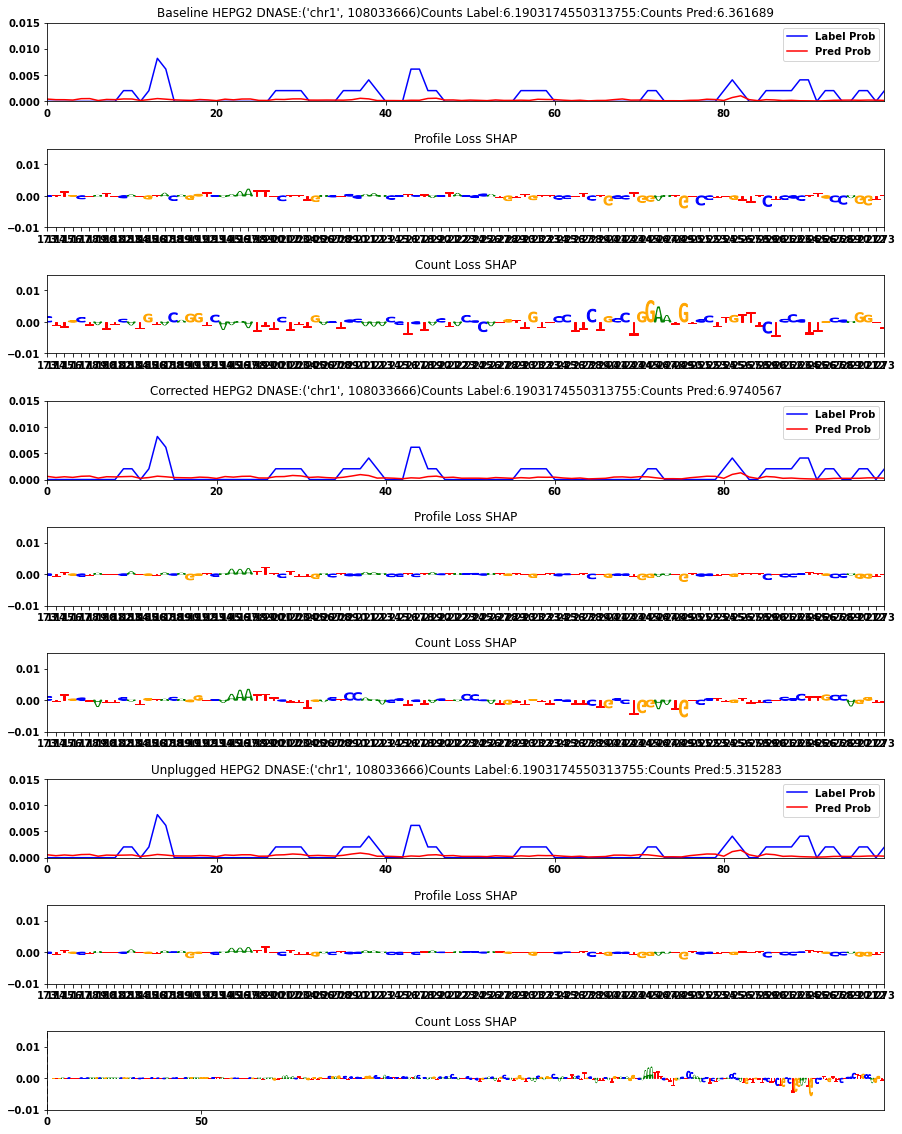

In [81]:
make_plot(baseline_region_vals,
        corrected_region_vals, 
        unplugged_region_vals,
        region,
        ymin_perf=minval_perf,
        ymax_perf=0.015,
        ymin_shap=-0.01,
        ymax_shap=0.015,
        xmin=0,
        xmax=100)